# Equity Valuation Models - Showcase

**A valuation is only as defensible as its assumptions - so every assumption is sourced, challenged, and logged.**

This notebook runs the framework end-to-end on an **illustrative** BHP sum-of-parts, entirely offline, and renders what it produces:

1. the **assumption-and-evidence ledger** (the spine) and its two credibility axes,
2. the **guardrails** that police each input,
3. the **WACC** build,
4. the **sum-of-the-parts** bridge to a per-share value,
5. a **WACC x commodity-price sensitivity** grid, and
6. the final **research note** - the ledger, rendered.

> ⚠️ **Every number below is a placeholder** chosen to exercise the machinery - this is **not** a real valuation of BHP. The remaining work is sourcing primary data and forming defensible judgements; see `templates/bhp_template.json` and `docs/DATA_ENTRY.md`.

## 0 · Setup - build the illustrative ledger (offline)

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")            # quiet pandas/yfinance import chatter
%matplotlib inline

# Make the repo importable whether this runs from the repo root or a notebooks/ folder.
_here = os.path.abspath(os.getcwd())
while _here != os.path.dirname(_here) and not os.path.isdir(os.path.join(_here, "src")):
    _here = os.path.dirname(_here)
sys.path.insert(0, _here); os.chdir(_here)

import pandas as pd
from IPython.display import Markdown, display

from examples.bhp_sotp_demo import build_ledger, build_sotp
from src.ledger import InputKind, VerificationStatus
from src.note import render_note
from src.excel_model import build_workbook

ledger, wacc = build_ledger()     # scaffold -> WACC bank -> commodity decks (all offline)
sotp = build_sotp(wacc)           # per-asset DCF -> divisions -> group bridge
ledger.set_result("value_per_share", round(sotp.value_per_share(), 2), unit="USD")

print(f"{ledger.company}  ({ledger.ticker})")
print(f"WACC: {wacc:.2%}    per-share (model US$): {sotp.value_per_share():,.2f}")

BHP Group Limited  (ILLUSTRATIVE)  (BHP.AX)
WACC: 8.53%    per-share (model US$): 7.95


## 1 · The ledger - two credibility axes

Every input records **where it came from** (`source`) *and* **whether a human has checked it** (`verified`) - orthogonally. An auto-scraped market figure is high-source but *unverified*; a hard-reasoned estimate is lower-source but *verified-by-you*. Discretionary judgements additionally carry a **rationale** - the tiered policy refuses to store one without it.

Note the **`as_of`** and **`citation`** columns: every figure is dated and sourced so it can be checked without second-guessing. BHP lists on the ASX in **AUD** (the scaffolded market data) but reports and is valued here in **USD** - so each row carries its own `unit`; watch the currency.

In [4]:
def _vshow(v):
    return "; ".join(f"{k}: {v[k]}" for k in v) if isinstance(v, dict) else v

rows = [{
    "key": k,
    "input": e.label,
    "value": _vshow(e.value),
    "unit": e.unit,
    "as_of": e.as_of,
    "source": e.source_type.name.replace("_", " ").title(),
    "citation": e.citation,
    "verified": "✓" if e.verification == VerificationStatus.VERIFIED else "—",
} for k, e in ledger.entries.items()]

pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows).set_index("key")

,input,value,unit,as_of,source,citation,verified
key,,,,,,,
group.share_price,Share price (last close),41.2,AUD,2026-06-15,External Data,ILLUSTRATIVE placeholder -- BHP.AX currentPrice; not a live pull,—
group.shares_outstanding,Shares outstanding,5068.0,m shares,2026-06-15,External Data,ILLUSTRATIVE placeholder -- BHP.AX sharesOutstanding; not a live pull,—
group.market_cap,Market capitalisation,208000.0,AUD m,2026-06-15,External Data,ILLUSTRATIVE placeholder -- BHP.AX marketCap; not a live pull,—
wacc.equity_beta_raw,Raw equity beta (yfinance),0.61,x,2026-06-15,External Data,ILLUSTRATIVE placeholder -- BHP.AX beta; not a live pull,—
wacc.currency_basis,WACC currency basis,USD,ccy,2026-06-19,Assumption,BHP functional currency,✓
wacc.risk_free,Risk-free rate,0.042,%,2026-06-19,External Data,"US 10Y Treasury, FRED 2026-06-15",✓
wacc.erp,Equity risk premium,0.048,%,2026-06-19,Analyst Estimate,"Damodaran implied ERP, Jun-2026",✓
wacc.equity_beta,Equity beta,0.95,x,2026-06-19,Analyst Estimate,"peers RIO/VALE/Anglo unlevered, re-levered to 15% target gearing",✓
wacc.cost_of_debt,Pre-tax cost of debt,0.053,%,2026-06-19,Company Filing,A-rated; rf + ~1.1% spread,✓


In [5]:
# One-line audit of the whole ledger
pd.DataFrame([ledger.audit_summary()])

,entries_total,verified,unverified,warnings_open,overrides_logged
0,16,12,4,0,0


## 2 · Guardrails - warn, never silently pass

Reasonableness checks run on every input as it is recorded (WACC > g, cost of debt > risk-free, capital weights sum to 1, long-run price vs spot...). They **warn**; the analyst may proceed only by logging a written **override**. Here every check passes, so there are no open warnings.

In [6]:
# Per-input reasonableness checks that ran (status of each)
checks = [{"input": k, **g} for k, e in ledger.entries.items() for g in e.guardrail_results]
print("Per-input checks:")
display(pd.DataFrame(checks) if checks else Markdown("_none recorded_"))

# WACC-level cross-checks, snapshotted under results["wacc"]
print()
print("WACC cross-checks:")
display(pd.DataFrame(ledger.results["wacc"].get("cross_checks", [])))

Per-input checks:


,input,check,status,message
0,wacc.risk_free,within_range,pass,"0.042 within [0.01, 0.08]"
1,wacc.erp,within_range,pass,"0.048 within [0.035, 0.075]"
2,wacc.equity_beta,within_range,pass,"0.95 within [0.7, 1.3]"
3,wacc.equity_beta,relever_gearing_matches_weights,pass,"beta re-levered at 15% gearing, consistent with weights"
4,wacc.tax_rate,within_range,pass,"0.3 within [0.0, 0.5]"
5,wacc.mv_equity,vs_scaffold_within,pass,208000 within 5% of scaffold 208000.0
6,ironore.price_deck,long_run_vs_spot,pass,long-run 75 within 30% of spot 105
7,copper.price_deck,long_run_vs_spot,pass,long-run 9000 within 30% of spot 9600
8,metcoal.price_deck,long_run_vs_spot,pass,long-run 170 within 30% of spot 205
9,potash.price_deck,long_run_vs_spot,pass,long-run 350 within 30% of spot 295



WACC cross-checks:


,check,status,message
0,within_range,pass,"0.08528348623853212 within [0.08, 0.12]"
1,cost_of_debt_gt_rf,pass,cost of debt 5.30% > risk-free 4.20%
2,weights_sum_to_1,pass,capital-structure weights sum to 1.0


## 3 · WACC - assembled from the ledger

In [7]:
keys = ["wacc.risk_free", "wacc.erp", "wacc.equity_beta", "wacc.cost_of_debt",
        "wacc.tax_rate", "wacc.mv_equity", "wacc.mv_debt"]
rows = [{"input": ledger.get(k).label, "value": ledger.get(k).value,
         "unit": ledger.get(k).unit, "as_of": ledger.get(k).as_of,
         "citation": ledger.get(k).citation}
        for k in keys if ledger.get(k)]

print(f"Cost of equity: {ledger.results['cost_of_equity']['value']:.2%}")
print(f"WACC:           {ledger.results['wacc']['value']:.2%}")
pd.DataFrame(rows).set_index("input")

Cost of equity: 8.76%
WACC:           8.53%


,value,unit,as_of,citation
input,,,,
Risk-free rate,0.042,%,2026-06-19,"US 10Y Treasury, FRED 2026-06-15"
Equity risk premium,0.048,%,2026-06-19,"Damodaran implied ERP, Jun-2026"
Equity beta,0.950,x,2026-06-19,"peers RIO/VALE/Anglo unlevered, re-levered to 15% target gearing"
Pre-tax cost of debt,0.053,%,2026-06-19,A-rated; rf + ~1.1% spread
Tax rate (for the discount),0.300,%,2026-06-19,AUS statutory rate
Market value of equity,208000.000,m,2026-06-19,"approx AUD price x shares, ~208,800m (illustrative; AUD basis)"
Market value of net debt,10000.000,m,2026-06-19,"BHP FY25 net debt (illustrative; USD ~10,000m)"


## 4 · Sum-of-the-parts - asset -> division -> equity -> per share

In [8]:
tbl = sotp.summary_table().copy()
tbl["Value"] = tbl["Value"].map(lambda v: f"{v:,.0f}")
tbl["% of EV"] = tbl["% of EV"].map(lambda v: f"{v:.0%}" if v == v else "")
tbl

,Value,% of EV
Component,,
Iron Ore (WAIO),"43,721",81%
Copper,"11,240",21%
Coal (met),"4,208",8%
Potash,"1,130",2%
Other assets,"2,000",4%
Less: Corporate (PV),"-8,000",-15%
Enterprise value,"54,298",100%
Less: Net debt,"-11,000",
Less: Minorities,"-3,000",


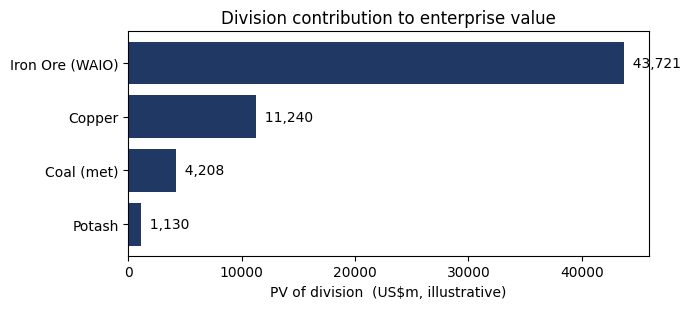

In [9]:
import matplotlib.pyplot as plt

dv = sotp.division_values()
names, vals = list(dv), [dv[n] for n in dv]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(names, vals, color="#1F3864")
ax.invert_yaxis()
ax.set_xlabel("PV of division  (US$m, illustrative)")
ax.set_title("Division contribution to enterprise value")
for i, v in enumerate(vals):
    ax.text(v, i, f"  {v:,.0f}", va="center")
plt.tight_layout(); plt.show()

## 5 · Sensitivity - WACC x commodity-price shift

Per-share value re-computed under a discount-rate band and a uniform price shift, via `SumOfParts.revalue()` (non-mutating - it does not touch the base case).

In [10]:
wacc_offs = [-0.015, -0.0075, 0.0, 0.0075, 0.015]
pfs = [0.85, 0.925, 1.0, 1.075, 1.15]

def _pf(pf):
    d = pf - 1.0
    return "base" if abs(d) < 1e-9 else f"{d:+.1%}"

grid = pd.DataFrame(
    {_pf(pf): [round(sotp.revalue(discount_rate=wacc + wo, price_factor=pf), 2) for wo in wacc_offs]
     for pf in pfs},
    index=[f"{wacc + wo:.2%}" for wo in wacc_offs],
)
grid.index.name = "WACC \\ price"
grid

,-15.0%,-7.5%,base,+7.5%,+15.0%
WACC \ price,,,,,
7.03%,4.48,6.45,8.41,10.37,12.33
7.78%,4.33,6.25,8.18,10.10,12.02
8.53%,4.18,6.06,7.95,9.84,11.73
9.28%,4.03,5.88,7.73,9.59,11.44
10.03%,3.89,5.70,7.52,9.34,11.16


## 6 · The research note - the ledger, rendered

The final deliverable. Its signature sections are the dated **Market data** table, the **key-assumptions & provenance** table (every discretionary input with its source, verification status, as-of date, and rationale), and a **model-integrity** appendix. The same `render_note()` writes the markdown file; `examples/bhp_sotp_demo.py` additionally emits the formatted Excel workbook.

In [11]:
display(Markdown(render_note(
    ledger, sotp,
    recommendation="HOLD  (ILLUSTRATIVE)",
    thesis=("_Placeholder thesis._ The framework supplies the valuation bridge and the "
            "audit trail; the view, and the verified inputs behind it, are the analyst's work."),
    illustrative=True,
)))

# BHP Group Limited  (ILLUSTRATIVE) (BHP.AX) — Equity Research Note

*Prepared 2026-06-19 · valuation basis USD; per-share in AUD*

> **⚠️ ILLUSTRATIVE — NOT INVESTMENT ADVICE.** Figures are placeholders to demonstrate the framework. Assumptions are unverified and do **not** reflect a real valuation. See the model-integrity appendix for what remains unverified.

## Recommendation

- **Rating:** HOLD  (ILLUSTRATIVE)
- **Target (per share):** 7.95 USD
- **Last price:** 41.20 AUD (as of 2026-06-15)  ·  target 7.95 USD — _FX conversion required before comparing (not applied)_

## Investment thesis

_Placeholder thesis._ The framework supplies the valuation bridge and the audit trail; the view, and the verified inputs behind it, are the analyst's work.

## Valuation — sum of the parts

Discount rate (WACC): **8.53%**  ·  cost of equity 8.76%

| Component (USDm) | Value | % of EV |
|---|---|---|
| Iron Ore (WAIO) | 43,721 | 81% |
| Copper | 11,240 | 21% |
| Coal (met) | 4,208 | 8% |
| Potash | 1,130 | 2% |
| Other assets | 2,000 | 4% |
| Less: Corporate (PV) | -8,000 | -15% |
| Enterprise value | 54,298 | 100% |
| Less: Net debt | -11,000 |  |
| Less: Minorities | -3,000 |  |
| Equity value | 40,298 |  |
| Shares (m) | 5,068 |  |
| Value per share | 7.952 |  |

## Market data (as-of)

| Market input | Value | Unit | As of | Source & citation | Verified |
|---|---|---|---|---|---|
| Share price (last close) | 41.2 | AUD | 2026-06-15 | External Data — ILLUSTRATIVE placeholder -- BHP.AX currentPrice; not a live pull | — |
| Shares outstanding | 5,068 | m shares | 2026-06-15 | External Data — ILLUSTRATIVE placeholder -- BHP.AX sharesOutstanding; not a live pull | — |
| Market capitalisation | 208,000 | AUD m | 2026-06-15 | External Data — ILLUSTRATIVE placeholder -- BHP.AX marketCap; not a live pull | — |
| Raw equity beta (yfinance) | 0.61 | x | 2026-06-15 | External Data — ILLUSTRATIVE placeholder -- BHP.AX beta; not a live pull | — |
| Market value of equity | 208,000 | m | 2026-06-19 | External Data — approx AUD price x shares, ~208,800m (illustrative; AUD basis) | ✓ |
| Market value of net debt | 10,000 | m | 2026-06-19 | Company Filing — BHP FY25 net debt (illustrative; USD ~10,000m) | ✓ |

## Key assumptions & provenance

| Input | Value | Unit | As of | Source & citation | Verified | Rationale |
|---|---|---|---|---|---|---|
| WACC currency basis | USD | ccy | 2026-06-19 | Assumption — BHP functional currency | ✓ | commodities USD-priced; convert final $/share to AUD at spot |
| Risk-free rate | 0.042 | % | 2026-06-19 | External Data — US 10Y Treasury, FRED 2026-06-15 | ✓ | matches the USD cash-flow basis |
| Equity risk premium (implied) | 0.048 | % | 2026-06-19 | Analyst Estimate — Damodaran implied ERP, Jun-2026 | ✓ | forward-looking implied preferred over backward historical |
| Equity beta (bottom_up) | 0.95 | x | 2026-06-19 | Analyst Estimate — peers RIO/VALE/Anglo unlevered, re-levered to 15% target gearing | ✓ | raw 5y beta distorted by the 2022 commodity spike |
| Pre-tax cost of debt (rating_implied) | 0.053 | % | 2026-06-19 | Company Filing — A-rated; rf + ~1.1% spread | ✓ | rating-implied |
| Tax rate (for the discount) | 0.3 | % | 2026-06-19 | External Data — AUS statutory rate | ✓ | statutory; royalties captured in opex, not in the tax rate |
| Iron ore 62% Fe CFR China | 2027: 95; 2028: 90; 2029: 85; 2030: 80; 2031: 78; long_run: 75 | USD/t | 2026-06-19 | Analyst Estimate — ILLUSTRATIVE; consensus front years + cost-support long-run | ✓ | placeholder deck -- verify against consensus / cost curves |
| Copper (LME) | 2027: 9500; 2028: 9300; 2029: 9200; 2030: 9100; 2031: 9000; long_run: 9000 | USD/t | 2026-06-19 | Analyst Estimate — ILLUSTRATIVE; consensus front years + cost-support long-run | ✓ | placeholder deck -- verify against consensus / cost curves |
| Met (coking) coal | 2027: 210; 2028: 195; 2029: 185; 2030: 180; 2031: 175; long_run: 170 | USD/t | 2026-06-19 | Analyst Estimate — ILLUSTRATIVE; consensus front years + cost-support long-run | ✓ | placeholder deck -- verify against consensus / cost curves |
| Potash (MOP) | 2027: 300; 2028: 310; 2029: 320; 2030: 330; 2031: 340; long_run: 350 | USD/t | 2026-06-19 | Analyst Estimate — ILLUSTRATIVE; consensus front years + cost-support long-run | ✓ | placeholder deck -- verify against consensus / cost curves |

## Model integrity

- Entries: 16  ·  verified: 12  ·  unverified: 4
- Open guardrail warnings: 0  ·  overrides logged: 0

---

*General information and educational material only, not financial product advice. Not licensed to provide financial advice. Verify against primary disclosures before any investment decision.*


### The Excel deliverable

In [12]:
wb = build_workbook(ledger, sotp, recommendation="HOLD  (ILLUSTRATIVE)")
print("Excel workbook generated in-memory. Sheets:")
for s in wb.sheetnames:
    print(f"  - {s}")
print()
print("Run  examples/bhp_sotp_demo.py  to write output/BHP_model.xlsx + the note to disk.")

Excel workbook generated in-memory. Sheets:
  - Cover
  - Valuation
  - WACC
  - Assumptions
  - Sensitivity

Run  examples/bhp_sotp_demo.py  to write output/BHP_model.xlsx + the note to disk.


## Making it real

Everything above is machinery exercised on placeholders. To produce a defensible valuation:

1. Fill `templates/bhp_template.json` with **primary-source** data (annual report, operational reviews, reserves & resources) - every value cited.
2. Run `python -m src.template_loader templates/bhp_template.json` for a readiness report of exactly what is still missing.
3. Once complete, it regenerates this note and the Excel model from your cited data - and drops the "illustrative" banner.

The code is the easy part; the judgement the ledger captures is the work. See [`docs/DATA_ENTRY.md`](docs/DATA_ENTRY.md) and [`docs/elicitation_design.md`](docs/elicitation_design.md).